In [1]:
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
import nltk
import numpy as np
from rouge_score import rouge_scorer

In [2]:
df = pd.read_csv('bbc_dataset_combined.csv')
df.drop(columns=['nama_file'], inplace=True)
df

,kategori,artikel_asli,rangkuman_asli
0,business,Ad sales boost Time Warner profit\n\nQuarterly...,TimeWarner said fourth quarter sales rose 2% t...
1,business,Dollar gains on Greenspan speech\n\nThe dollar...,The dollar has hit its highest level against t...
2,business,Yukos unit buyer faces loan claim\n\nThe owner...,Yukos' owner Menatep Group says it will ask Ro...
3,business,High fuel prices hit BA's profits\n\nBritish A...,"Rod Eddington, BA's chief executive, said the ..."
4,business,Pernod takeover talk lifts Domecq\n\nShares in...,Pernod has reduced the debt it took on to fund...
...,...,...,...
2220,tech,BT program to beat dialler scams\n\nBT is intr...,BT is introducing two initiatives to help beat...
2221,tech,Spam e-mails tempt net shoppers\n\nComputer us...,A third of them read unsolicited junk e-mail a...
2222,tech,Be careful how you code\n\nA new European dire...,This goes to the heart of the European project...
2223,tech,US cyber security chief resigns\n\nThe man mak...,Amit Yoran was director of the National Cyber ...


In [3]:
print(df.duplicated(subset=['artikel_asli']).sum())
print(df.duplicated(subset=['rangkuman_asli']).sum())

98
144


In [4]:
df = df.drop_duplicates(subset=['artikel_asli','rangkuman_asli'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2127 entries, 0 to 2224
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   kategori        2127 non-null   object
 1   artikel_asli    2127 non-null   object
 2   rangkuman_asli  2127 non-null   object
dtypes: object(3)
memory usage: 66.5+ KB


In [5]:
def cleaning(text):
    text = str(text)
    text = re.sub(r'\s+',' ',text)
    return text

df['artikel_asli'] = df['artikel_asli'].apply(cleaning)
df['rangkuman_asli'] = df['rangkuman_asli'].apply(cleaning)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20500\393972380.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['artikel_asli'] = df['artikel_asli'].apply(cleaning)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20500\393972380.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rangkuman_asli'] = df['rangkuman_asli'].apply(cleaning)


In [6]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 2127 entries, 0 to 2224
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   kategori        2127 non-null   object
 1   artikel_asli    2127 non-null   object
 2   rangkuman_asli  2127 non-null   object
dtypes: object(3)
memory usage: 66.5+ KB


kategori          0
artikel_asli      0
rangkuman_asli    0
dtype: int64

In [7]:
def word_count(sentence):
    sentences = sentence.split()
    return len(sentences)

df['artikel_asli_jumlah']  = df['artikel_asli'].apply(word_count)
df['rangkuman_asli_jumlah']  = df['rangkuman_asli'].apply(word_count)
df.head(10)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20500\2391446194.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['artikel_asli_jumlah']  = df['artikel_asli'].apply(word_count)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20500\2391446194.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rangkuman_asli_jumlah']  = df['rangkuman_asli'].apply(word_count)


,kategori,artikel_asli,rangkuman_asli,artikel_asli_jumlah,rangkuman_asli_jumlah
0,business,Ad sales boost Time Warner profit Quarterly pr...,TimeWarner said fourth quarter sales rose 2% t...,421,134
1,business,Dollar gains on Greenspan speech The dollar ha...,The dollar has hit its highest level against t...,384,158
2,business,Yukos unit buyer faces loan claim The owners o...,Yukos' owner Menatep Group says it will ask Ro...,264,121
3,business,High fuel prices hit BA's profits British Airw...,"Rod Eddington, BA's chief executive, said the ...",406,197
4,business,Pernod takeover talk lifts Domecq Shares in UK...,Pernod has reduced the debt it took on to fund...,265,106
5,business,Japan narrowly escapes recession Japan's econo...,"On an annual basis, the data suggests annual g...",184,68
6,business,Jobs growth still slow in the US The US create...,The job gains mean that President Bush can cel...,284,136
7,business,"India calls for fair trade rules India, which ...",At a conference on developing enterprise hoste...,321,158
8,business,Ethiopia's crop production up 24% Ethiopia pro...,"In 2003, crop production totalled 11.49 millio...",229,96
9,business,Court rejects $280bn tobacco case A US governm...,A US government claim accusing the country's b...,227,89


In [8]:
df.describe()

,artikel_asli_jumlah,rangkuman_asli_jumlah
count,2127.000000,2127.000000
mean,384.112835,165.354960
std,241.399741,110.295504
min,89.000000,38.000000
25%,245.000000,103.000000
50%,331.000000,142.000000
75%,471.000000,202.000000
max,4432.000000,2073.000000


Upper whisker: 810.0
Q3: 471.0
Q2: 331.0
Q1: 245.0
Lower whisker: 89.0


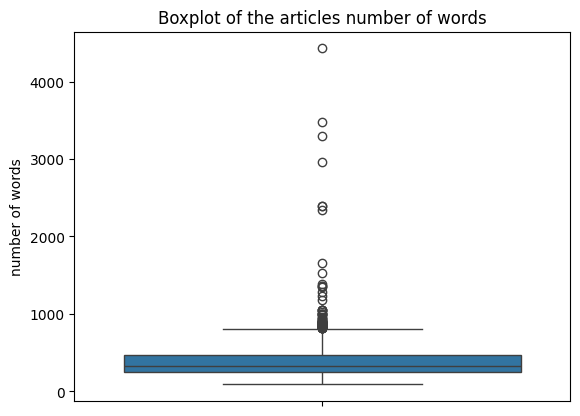

In [11]:
sns.boxplot(df['artikel_asli_jumlah'])
plt.ylabel("number of words")
plt.title("Boxplot of the articles number of words")

lines = plt.gca().lines[:6]
all_lines = [lines[i].get_ydata()[0] for i in range(5)]

Q1,Q3,article_lower_whisker,article_upper_whisker, Q2 = all_lines

print("Upper whisker:", article_upper_whisker)
print("Q3:", Q3)
print("Q2:", Q2)
print("Q1:", Q1)
print("Lower whisker:", article_lower_whisker)

Upper whisker: 350.0
Q3: 202.0
Q2: 142.0
Q1: 103.0
Lower whisker: 38.0


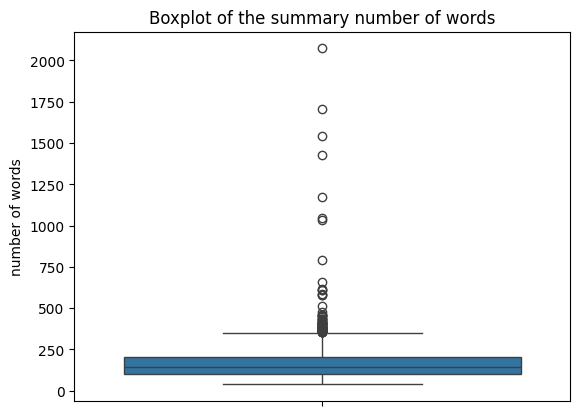

In [12]:
sns.boxplot(df['rangkuman_asli_jumlah'])
plt.ylabel("number of words")
plt.title("Boxplot of the summary number of words")

lines = plt.gca().lines[:6]
all_lines = [lines[i].get_ydata()[0] for i in range(5)]

Q1,Q3,summary_lower_whisker,summary_upper_whisker, Q2 = all_lines

print("Upper whisker:", summary_upper_whisker)
print("Q3:", Q3)
print("Q2:", Q2)
print("Q1:", Q1)
print("Lower whisker:", summary_lower_whisker)

In [13]:
new_df = df[(df['artikel_asli_jumlah'] <= article_upper_whisker) & (df['rangkuman_asli_jumlah'] <= summary_upper_whisker)]
new_df.info()

         

<class 'pandas.core.frame.DataFrame'>
Index: 2048 entries, 0 to 2223
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   kategori               2048 non-null   object
 1   artikel_asli           2048 non-null   object
 2   rangkuman_asli         2048 non-null   object
 3   artikel_asli_jumlah    2048 non-null   int64 
 4   rangkuman_asli_jumlah  2048 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 96.0+ KB


<Axes: xlabel='kategori'>

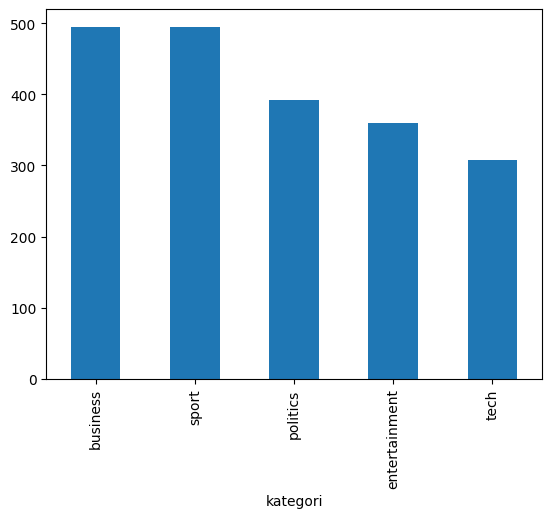

In [14]:
new_df['kategori'].value_counts().plot(kind='bar')

In [91]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
import numpy as np
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

In [92]:
def extract(article, model):
    try:
        parser = PlaintextParser.from_string(article, Tokenizer("english"))
        sentence_result = model(parser.document, sentences_count=3)
        return " ".join([str(sentence) for sentence in sentence_result])
    except:
        return ""

In [93]:
def evaluation(model_type, model, dataframe):
    rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    total_r1, total_r2, total_rL = 0, 0, 0
    
    for index, row in dataframe.iterrows():
        article = row['artikel_asli']
        summarized = row['rangkuman_asli']
        
        pred = extract(article, model)
        skor = rouge.score(summarized, pred)
        
        total_r1 += skor['rouge1'].fmeasure
        total_r2 += skor['rouge2'].fmeasure
        total_rL += skor['rougeL'].fmeasure

    total_data = len(dataframe)
    print(f"{model_type}:")
    print(f"ROUGE-1: {(total_r1 / total_data) * 100:.2f}%")
    print(f"ROUGE-2: {(total_r2 / total_data) * 100:.2f}%")
    print(f"ROUGE-L: {(total_rL / total_data) * 100:.2f}%\n")

In [94]:
def mmr_summarizer(text, num_sentences=3, lambda_param=0.5, **kwargs):
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)
    
    doc_vector = np.asarray(tfidf_matrix.mean(axis=0))
    
    relevance_scores = cosine_similarity(tfidf_matrix, doc_vector).flatten()
    
    unselected = list(range(len(sentences)))
    selected = []
    
    first_idx = int(np.argmax(relevance_scores))
    selected.append(first_idx)
    unselected.remove(first_idx)

    while len(selected) < num_sentences and len(unselected) > 0:
        mmr_scores = {}
        
        selected_matrix = tfidf_matrix[np.array(selected)]
        
        for i in unselected:
            rel = relevance_scores[i]
            sim_to_selected = cosine_similarity(tfidf_matrix[i], selected_matrix).flatten()
            redundancy = np.max(sim_to_selected)
            mmr_scores[i] = lambda_param * rel - (1 - lambda_param) * redundancy
            
        best_idx = max(mmr_scores, key=mmr_scores.get)
        selected.append(best_idx)
        unselected.remove(best_idx)

    selected.sort()
    return " ".join([sentences[i] for i in selected])
        


In [95]:

def custom_mmr_summarizer(text, num_sentences=3, lambda_param=0.5, position_bonus=0.0001, **kwargs):
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text

    try:
        vectorizer = TfidfVectorizer(stop_words='english')
        tfidf_matrix = vectorizer.fit_transform(sentences)
        
        doc_vector = np.asarray(tfidf_matrix.mean(axis=0))
        
        relevance_scores = cosine_similarity(tfidf_matrix, doc_vector).flatten()
        
        for i in range(min(2, len(sentences))):
            relevance_scores[i] += position_bonus * (1.5 if i == 0 else 1.0)   #koenci jaw
            
        unselected = list(range(len(sentences)))
        selected = []
        
        first_idx = int(np.argmax(relevance_scores))
        selected.append(first_idx)
        unselected.remove(first_idx)

        while len(selected) < num_sentences and len(unselected) > 0:
            mmr_scores = {}
            
            selected_matrix = tfidf_matrix[np.array(selected)]
            
            for i in unselected:
                rel = relevance_scores[i]
                sim_to_selected = cosine_similarity(tfidf_matrix[i], selected_matrix).flatten()
                redundancy = np.max(sim_to_selected)
                mmr_scores[i] = lambda_param * rel - (1 - lambda_param) * redundancy
                
            best_idx = max(mmr_scores, key=mmr_scores.get)
            selected.append(best_idx)
            unselected.remove(best_idx)

        selected.sort()
        return " ".join([sentences[i] for i in selected])
        
    except Exception as e:
        print("Error pada baris:", e)
        return text

In [96]:
def custom_textrank_with_bias(text, num_sentences=3, damping_factor=0.85, position_bonus=1e-6):
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text
    
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    np.fill_diagonal(similarity_matrix, 0)
    
    nx_graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(nx_graph, alpha=damping_factor)
    
    for i in range(min(2, len(sentences))):
        scores[i] += position_bonus * (1.5 if i == 0 else 1.0) #koenci adalah jaw
            
    ranked_sentences = sorted(((scores[i], s, i) for i, s in enumerate(sentences)), reverse=True)
    
    top_sentences = sorted(ranked_sentences[:num_sentences], key=lambda x: x[2])
    
    return " ".join([sentence for _, sentence, _ in top_sentences])

In [97]:
def evaluate_custom_model(model_name, model_func, dataframe, bonus_val=1e-6):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    total_r1, total_r2, total_rL = 0.0, 0.0, 0.0
    total_rows = len(dataframe)
    
    for _, row in dataframe.iterrows():
        article = row['artikel_asli']
        reference = row['rangkuman_asli']
        
        try:
            predicted = model_func(article, num_sentences=3, position_bonus=bonus_val)
        except Exception:
            predicted = ""
            
        scores = scorer.score(reference, predicted)
        total_r1 += scores['rouge1'].fmeasure
        total_r2 += scores['rouge2'].fmeasure
        total_rL += scores['rougeL'].fmeasure


    print(f"{model_name}:")
    print(f"ROUGE-1: {(total_r1 / total_rows) * 100:.2f}%")
    print(f"ROUGE-2: {(total_r2 / total_rows) * 100:.2f}%")
    print(f"ROUGE-L: {(total_rL / total_rows) * 100:.2f}%\n")

In [98]:
evaluation("TextRank", TextRankSummarizer(), new_df)
evaluate_custom_model("TextRank with bias", custom_textrank_with_bias, new_df)
evaluate_custom_model("mmr",mmr_summarizer,new_df)
evaluate_custom_model("mmr with bias",custom_mmr_summarizer,new_df)


TextRank:
ROUGE-1: 53.77%
ROUGE-2: 42.55%
ROUGE-L: 40.12%

TextRank with bias:
ROUGE-1: 59.23%
ROUGE-2: 55.04%
ROUGE-L: 44.72%

mmr:
ROUGE-1: 51.07%
ROUGE-2: 42.81%
ROUGE-L: 38.87%

mmr with bias:
ROUGE-1: 51.08%
ROUGE-2: 42.83%
ROUGE-L: 38.87%



In [99]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

train_df, test_df = train_test_split(
    new_df, 
    test_size=0.2, 
    random_state=42, 
    stratify=new_df['kategori']
)

val_df, test_df = train_test_split(
    test_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=test_df['kategori']
)

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)

dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

dataset

DatasetDict({
    train: Dataset({
        features: ['kategori', 'artikel_asli', 'rangkuman_asli', 'artikel_asli_jumlah', 'rangkuman_asli_jumlah'],
        num_rows: 1638
    })
    validation: Dataset({
        features: ['kategori', 'artikel_asli', 'rangkuman_asli', 'artikel_asli_jumlah', 'rangkuman_asli_jumlah'],
        num_rows: 205
    })
    test: Dataset({
        features: ['kategori', 'artikel_asli', 'rangkuman_asli', 'artikel_asli_jumlah', 'rangkuman_asli_jumlah'],
        num_rows: 205
    })
})

In [100]:
import torch, gc
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
from tqdm.auto import tqdm

In [101]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_anu = "sshleifer/distilbart-cnn-12-6"
tokenizer_bart = AutoTokenizer.from_pretrained(model_anu)
model = AutoModelForSeq2SeqLM.from_pretrained(model_anu, use_safetensors=True).to(device)

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_r1, total_r2, total_rL = 0.0, 0.0, 0.0


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 356/356 [00:00<00:00, 5273.56it/s]


In [102]:
for index, row in test_df.iterrows():
    article = row['artikel_asli']
    summary = row['rangkuman_asli']
    
    inputs = tokenizer_bart(article, max_length=1024, truncation=True, return_tensors="pt").to(device)
    
    summary_ids = model.generate(
        inputs["input_ids"], 
        max_length=150, 
        min_length=40, 
        length_penalty=2.0, 
        num_beams=4, 
        early_stopping=True
    )
        
    pred = tokenizer_bart.decode(summary_ids[0], skip_special_tokens=True)
    
    skor = scorer.score(summary, pred)
    total_r1 += skor['rouge1'].fmeasure
    total_r2 += skor['rouge2'].fmeasure
    total_rL += skor['rougeL'].fmeasure

jumlah_data = len(test_df)
print("Evaluasi distilBART")
print("ROUGE-1:", (total_r1 / jumlah_data) * 100)
print("ROUGE-2:", (total_r2 / jumlah_data) * 100)
print("ROUGE-L:", (total_rL / jumlah_data) * 100)

Evaluasi distilBART
ROUGE-1: 35.07620335604697
ROUGE-2: 24.282551729823584
ROUGE-L: 25.961531464050523


In [103]:
max_input_length = int(article_upper_whisker)
max_target_length = int(summary_upper_whisker)

def preprocess_function(examples):
    model_inputs = tokenizer_bart(
        examples["artikel_asli"], 
        max_length=max_input_length,
        truncation=True,
    )
    labels = tokenizer_bart(
        text_target=examples["rangkuman_asli"], 
        max_length=max_target_length, 
        truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [104]:
tokenized_datasets = dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 205/205 [00:00<00:00, 4270.93 examples/s]


In [105]:
tokenized_datasets = tokenized_datasets.remove_columns(dataset["train"].column_names)

In [106]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer_bart, model=model)

In [107]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    decoded_preds = tokenizer_bart.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer_bart.pad_token_id)
    decoded_labels = tokenizer_bart.batch_decode(labels, skip_special_tokens=True)
    
    decoded_preds = ["\n".join(sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(sent_tokenize(label.strip())) for label in decoded_labels]
    
    total_r1, total_r2, total_rL = 0.0, 0.0, 0.0
    for i in range(len(decoded_preds)):
        skor = scorer.score(decoded_labels[i], decoded_preds[i])
        total_r1 += skor['rouge1'].fmeasure 
        total_r2 += skor['rouge2'].fmeasure 
        total_rL += skor['rougeL'].fmeasure 
        
    total_data = len(decoded_preds)
    
    # dict buat trainer
    return {
        "rouge1": (total_r1 / total_data) * 100,
        "rouge2": (total_r2 / total_data) * 100,
        "rougeL": (total_rL / total_data) * 100, 
    }

In [108]:
batch_size = 2
num_train_epochs = 3
model_name = "distilbart-cnn-12-6"

model.config.use_cache = False

args = Seq2SeqTrainingArguments(
    output_dir=f"{model_name}-finetuned-BBC",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5.6e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=4,        
    gradient_checkpointing=True,         
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=num_train_epochs,
    predict_with_generate=True,
    bf16=True,                            
    generation_num_beams=1,             
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
)

In [109]:
trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [110]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print("VRAM terpakai:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")

VRAM terpakai: 1.23 GB


In [111]:
trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,0.525727,0.135866,63.939793,55.519807,46.959898
2,0.366197,0.121302,69.546008,63.028223,52.389479
3,0.240140,0.116934,71.355837,65.365815,54.256629


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.22s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=615, training_loss=0.4687248071034749, metrics={'train_runtime': 898.0073, 'train_samples_per_second': 5.472, 'train_steps_per_second': 0.685, 'total_flos': 3967776351141888.0, 'train_loss': 0.4687248071034749, 'epoch': 3.0})

In [112]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_r1, total_r2, total_rL = 0.0, 0.0, 0.0

for index, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluasi distilBART Fine-tuned"):
    article = row['artikel_asli']
    summary = row['rangkuman_asli']
    
    inputs = tokenizer_bart(article, max_length=1024, truncation=True, return_tensors="pt").to(device)
    
    summary_ids = model.generate(
        inputs["input_ids"], 
        max_length=150, 
        min_length=40, 
        length_penalty=2.0, 
        num_beams=4, 
        early_stopping=True
    )
    
    pred = tokenizer_bart.decode(summary_ids[0], skip_special_tokens=True)
    skor = scorer.score(summary, pred)
    total_r1 += skor['rouge1'].fmeasure
    total_r2 += skor['rouge2'].fmeasure
    total_rL += skor['rougeL'].fmeasure

jumlah_data = len(test_df)
print("evaluasi distilBART Fine-tuned")
print(f"ROUGE-1: {(total_r1 / jumlah_data) * 100:.2f}%")
print(f"ROUGE-2: {(total_r2 / jumlah_data) * 100:.2f}%")
print(f"ROUGE-L: {(total_rL / jumlah_data) * 100:.2f}%")

Evaluasi distilBART Fine-tuned: 100%|██████████| 205/205 [05:35<00:00,  1.64s/it]

evaluasi distilBART Fine-tuned
ROUGE-1: 72.08%
ROUGE-2: 65.96%
ROUGE-L: 54.53%


In [113]:
del model 
gc.collect()
torch.cuda.empty_cache()
print("VRAM terpakai:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")

VRAM terpakai: 3.69 GB


In [114]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_name_t5 = "t5-base" 
tokenizer_t5 = AutoTokenizer.from_pretrained(model_name_t5)
model_t5 = AutoModelForSeq2SeqLM.from_pretrained(model_name_t5,use_safetensors = True).to(device)

prefix = "summarize: "

c:\Users\LENOVO\anaconda3\envs\ia\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 257/257 [00:00<00:00, 11681.02it/s]


In [115]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

total_r1_t5, total_r2_t5, total_rL_t5 = 0.0, 0.0, 0.0
for index, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluasi T5 Polos"):
    article = row['artikel_asli']
    summary = row['rangkuman_asli']
    
    input_text = "summarize: " + article
    
    inputs = tokenizer_t5(input_text, max_length=1024, truncation=True, return_tensors="pt").to(device)
    
    summary_ids = model_t5.generate(
        inputs["input_ids"], 
        max_length=150, 
        min_length=40, 
        length_penalty=2.0, 
        num_beams=4, 
        early_stopping=True
    )
        
    pred = tokenizer_t5.decode(summary_ids[0], skip_special_tokens=True)
    
    skor = scorer.score(summary, pred)
    total_r1_t5 += skor['rouge1'].fmeasure
    total_r2_t5 += skor['rouge2'].fmeasure
    total_rL_t5 += skor['rougeL'].fmeasure

jumlah_data = len(test_df)
print("Evaluasi t5 polos")
print(f"ROUGE-1: {(total_r1_t5 / jumlah_data) * 100:.2f}%")
print(f"ROUGE-2: {(total_r2_t5 / jumlah_data) * 100:.2f}%")
print(f"ROUGE-L: {(total_rL_t5 / jumlah_data) * 100:.2f}%")

Evaluasi T5 Polos: 100%|██████████| 205/205 [03:44<00:00,  1.10s/it]

Evaluasi t5 polos
ROUGE-1: 32.77%
ROUGE-2: 21.95%
ROUGE-L: 24.40%


In [116]:
def preprocess_function_t5(examples):
    inputs = [prefix + doc for doc in examples["artikel_asli"]]
    
    model_inputs = tokenizer_t5(
        inputs, 
        max_length=max_input_length, 
        truncation=True,
    )
    
    labels = tokenizer_t5(
        text_target=examples["rangkuman_asli"], 
        max_length=max_target_length, 
        truncation=True
    )
    
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [117]:
tokenized_datasets_t5 = dataset.map(preprocess_function_t5, batched=True)
tokenized_datasets_t5 = tokenized_datasets_t5.remove_columns(dataset["train"].column_names)

data_collator_t5 = DataCollatorForSeq2Seq(tokenizer=tokenizer_t5, model=model_t5)

Map: 100%|██████████| 205/205 [00:00<00:00, 3306.22 examples/s]


In [122]:
def compute_metrics_t5(eval_pred):
    predictions, labels = eval_pred
    labels = np.where(labels != -100, labels, tokenizer_t5.pad_token_id)
    decoded_preds = tokenizer_t5.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer_t5.pad_token_id)
    decoded_labels = tokenizer_t5.batch_decode(labels, skip_special_tokens=True)
    
    decoded_preds = ["\n".join(sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(sent_tokenize(label.strip())) for label in decoded_labels]
    
    total_r1, total_r2, total_rL = 0.0, 0.0, 0.0
    for i in range(len(decoded_preds)):
        skor = scorer.score(decoded_labels[i], decoded_preds[i])
        total_r1 += skor['rouge1'].fmeasure 
        total_r2 += skor['rouge2'].fmeasure 
        total_rL += skor['rougeL'].fmeasure 
        
    total_data = len(decoded_preds)
    return {
        "rouge1": (total_r1 / total_data) * 100,
        "rouge2": (total_r2 / total_data) * 100,
        "rougeL": (total_rL / total_data) * 100, 
    }


In [123]:
batch_size = 2
num_train_epochs_t5 = 3

args_t5 = Seq2SeqTrainingArguments(
    output_dir=f"{model_name_t5}-finetuned-BBC",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5.6e-5,
    per_device_train_batch_size=batch_size, 
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=4,        
    gradient_checkpointing=True,         
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=num_train_epochs_t5, 
    predict_with_generate=True,
    bf16=True,                         
    generation_num_beams=1,             
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
)


In [124]:
trainer_t5 = Seq2SeqTrainer(
    model=model_t5,
    args=args_t5,
    train_dataset=tokenized_datasets_t5["train"],
    eval_dataset=tokenized_datasets_t5["validation"],
    data_collator=data_collator_t5,
    compute_metrics=compute_metrics_t5
)

In [126]:
print("VRAM terpakai:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")
gc.collect()
torch.cuda.empty_cache()
print("VRAM terpakai:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")

VRAM terpakai: 9.07 GB
VRAM terpakai: 7.28 GB


In [127]:
trainer_t5.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,0.734392,0.181865,17.558484,15.738876,17.205267
2,0.759999,0.173591,17.968308,16.167993,17.654411
3,0.659707,0.171542,18.023877,16.346007,17.747077


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.92s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=615, training_loss=0.775678269843745, metrics={'train_runtime': 4033.4053, 'train_samples_per_second': 1.218, 'train_steps_per_second': 0.152, 'total_flos': 3429672248309760.0, 'train_loss': 0.775678269843745, 'epoch': 3.0})

In [128]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_r1, total_r2, total_rL = 0.0, 0.0, 0.0

for index, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluasi T5 Fine-tuned"):
    article = row['artikel_asli']
    summary = row['rangkuman_asli']

    input_text = "summarize: " + article

    
    inputs = tokenizer_t5(input_text, max_length=1024, truncation=True, return_tensors="pt").to(device)
    
    summary_ids = model_t5.generate(
        inputs["input_ids"], 
        max_length=150, 
        min_length=40, 
        length_penalty=2.0, 
        num_beams=4, 
        early_stopping=True
    )
    
    pred = tokenizer_t5.decode(summary_ids[0], skip_special_tokens=True)
    skor = scorer.score(summary, pred)
    total_r1 += skor['rouge1'].fmeasure
    total_r2 += skor['rouge2'].fmeasure
    total_rL += skor['rougeL'].fmeasure

jumlah_data = len(test_df)
print("Evaluasi T5 Fine-tuned")
print(f"ROUGE-1: {(total_r1 / jumlah_data) * 100:.2f}%")
print(f"ROUGE-2: {(total_r2 / jumlah_data) * 100:.2f}%")
print(f"ROUGE-L: {(total_rL / jumlah_data) * 100:.2f}%")

Evaluasi T5 Fine-tuned: 100%|██████████| 205/205 [12:15<00:00,  3.59s/it]

Evaluasi T5 Fine-tuned
ROUGE-1: 64.57%
ROUGE-2: 56.17%
ROUGE-L: 47.56%
